<a href="https://colab.research.google.com/github/Tejaaswini/connected-coverage-swarm-sim/blob/main/connected-coverage-swarm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch, torch.nn.functional as F

DELTAS = torch.tensor([[0,0],[-1,0],[1,0],[0,-1],[0,1]], dtype=torch.long)  # STAY,UP,DOWN,LEFT,RIGHT

class Cfg:
    def __init__(s, **k):
        s.grid_size=32; s.n_agents=4; s.comm_radius=4; s.sense_radius=2
        s.obs_window=7; s.max_steps=256; s.num_envs=4096
        s.coverage_reward_scale=1.0; s.disconnect_penalty=1.0; s.seed=0
        for kk,vv in k.items(): setattr(s,kk,vv)
    @property
    def obs_dim(s): return s.obs_window*s.obs_window+2+1+1
    @property
    def n_actions(s): return 5

class SwarmEnv:
    def __init__(s, cfg, device):
        s.cfg=cfg; s.device=device; s.B=cfg.num_envs; s.N=cfg.n_agents
        s.gen=torch.Generator(device=device); s.gen.manual_seed(cfg.seed)
        s.deltas=DELTAS.to(device)
        g=cfg.grid_size
        s.pos=torch.zeros(s.B,s.N,2,dtype=torch.long,device=device)
        s.visited=torch.zeros(s.B,g,g,dtype=torch.bool,device=device)
        s.t=torch.zeros(s.B,dtype=torch.long,device=device)
        s.ep_len=torch.zeros(s.B,device=device)
        c=g//2
        base=[(c,c),(c-1,c),(c,c-1),(c+1,c+1)][:s.N]
        while len(base)<s.N: base.append((c,c))
        s.base=torch.tensor(base,dtype=torch.long,device=device)
        s.reset(torch.ones(s.B,dtype=torch.bool,device=device))

    def reset(s, mask):
        g=s.cfg.grid_size; idx=mask.nonzero(as_tuple=False).squeeze(-1)
        if idx.numel()==0: return
        b=idx.numel()
        jit=torch.randint(-1,2,(b,1,2),generator=s.gen,device=s.device)
        st=(s.base.unsqueeze(0)+jit).clamp(0,g-1)
        s.pos[idx]=st; s.visited[idx]=False; s.t[idx]=0; s.ep_len[idx]=0.0
        s._cover(idx)

    def _cover(s, idx):
        rs=s.cfg.sense_radius; g=s.cfg.grid_size
        offs=torch.arange(-rs,rs+1,device=s.device)
        dr,dc=torch.meshgrid(offs,offs,indexing='ij'); k=dr.numel()
        pos=s.pos[idx]
        rows=(pos[...,0:1]+dr.reshape(1,1,k)).clamp(0,g-1)
        cols=(pos[...,1:2]+dc.reshape(1,1,k)).clamp(0,g-1)
        bb=torch.arange(idx.numel(),device=s.device).view(-1,1,1).expand_as(rows)
        sub=s.visited[idx]
        sub[bb.reshape(-1),rows.reshape(-1),cols.reshape(-1)]=True
        s.visited[idx]=sub

    def _adjacency(s):
        diff=(s.pos.unsqueeze(2)-s.pos.unsqueeze(1)).abs()
        cheb=diff.max(dim=-1).values
        adj=cheb<=s.cfg.comm_radius
        eye=torch.eye(s.N,dtype=torch.bool,device=s.device)
        return adj|eye

    def _connected(s, adj):
        A=adj.float(); reach=adj.float()
        for _ in range(s.N-1): reach=(reach@A>0).float()
        return (reach>0).all(dim=(1,2))

    def observe(s):
        cfg=s.cfg; w=cfg.obs_window; p=w//2
        padded=F.pad(s.visited.float(),(p,p,p,p))
        ri=s.pos[...,0:1]+torch.arange(w,device=s.device)
        ci=s.pos[...,1:2]+torch.arange(w,device=s.device)
        bidx=torch.arange(s.B,device=s.device).view(-1,1,1,1)
        patch=padded[bidx,ri.unsqueeze(-1),ci.unsqueeze(-2)]
        adj=s._adjacency()
        nb=(adj.float().sum(-1)-1.0).unsqueeze(-1)/max(1,s.N-1)
        own=s.pos.float()/(cfg.grid_size-1)
        glob=s.visited.float().mean(dim=(1,2)).view(-1,1,1).expand(-1,s.N,1)
        return torch.cat([patch.flatten(2),own,nb,glob],dim=-1)

    def step(s, actions):
        cfg=s.cfg
        delta=s.deltas[actions]
        s.pos=(s.pos+delta).clamp(0,cfg.grid_size-1)
        s.t+=1
        before=s.visited.float().sum(dim=(1,2))
        s._cover(torch.arange(s.B,device=s.device))
        after=s.visited.float().sum(dim=(1,2))
        gain=after-before
        adj=s._adjacency(); connected=s._connected(adj)
        total=cfg.grid_size**2
        reward=cfg.coverage_reward_scale*gain/total-(~connected).float()*cfg.disconnect_penalty
        timeout=s.t>=cfg.max_steps
        done=(~connected)|timeout
        s.ep_len+=1.0
        info={'connected':connected,'coverage':(after/total),'ep_len':s.ep_len.clone(),'done':done.clone()}
        if done.any(): s.reset(done)
        return s.observe(),reward,done,info

In [2]:
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", dev)

print("\n=== shape & coverage-climb check (B=4096, N=4, 32x32) ===")
env = SwarmEnv(Cfg(num_envs=4096), dev)
obs = env.observe()
print("obs shape:", tuple(obs.shape), "expected:", (4096, 4, Cfg().obs_dim))
cov = []
for _ in range(60):
    a = torch.randint(0, 5, (env.B, env.N), generator=env.gen, device=dev)
    obs, r, d, info = env.step(a)
    cov.append(info['coverage'].mean().item())
print("coverage t=0..59 (mean over envs): %.3f -> %.3f" % (cov[0], cov[-1]))
print("climbs:", cov[-1] > cov[0])

print("\n=== adjacency / connectivity unit checks ===")
e = SwarmEnv(Cfg(num_envs=2, n_agents=3, grid_size=8, comm_radius=2), dev)
e.pos[0] = torch.tensor([[4,4],[4,5],[5,4]], device=dev)   # clustered -> connected
e.pos[1] = torch.tensor([[0,0],[7,7],[4,4]], device=dev)   # one flung away -> disconnected
adj = e._adjacency()
print("symmetric:", bool((adj==adj.transpose(1,2)).all()), "| self-loops:", bool(adj.diagonal(dim1=1,dim2=2).all()))
conn = e._connected(adj)
print("env0 connected (expect True):", bool(conn[0]), "| env1 connected (expect False):", bool(conn[1]))

print("\n=== disconnection triggers done ===")
e2 = SwarmEnv(Cfg(num_envs=1, n_agents=2, grid_size=8, comm_radius=1, max_steps=999), dev)
e2.pos[0] = torch.tensor([[0,0],[7,7]], device=dev)
_, r, d, info = e2.step(torch.zeros(1, 2, dtype=torch.long, device=dev))
print("done on disconnect (expect True):", bool(d[0]), "| reward<0 (expect True):", float(r[0]) < 0)

device: cuda

=== shape & coverage-climb check (B=4096, N=4, 32x32) ===
obs shape: (4096, 4, 53) expected: (4096, 4, 53)
coverage t=0..59 (mean over envs): 0.049 -> 0.081
climbs: True

=== adjacency / connectivity unit checks ===
symmetric: True | self-loops: True
env0 connected (expect True): True | env1 connected (expect False): False

=== disconnection triggers done ===
done on disconnect (expect True): True | reward<0 (expect True): True


In [3]:
import torch.nn as nn

def layer_init(layer, std=2**0.5, bias=0.0):
    nn.init.orthogonal_(layer.weight, std); nn.init.constant_(layer.bias, bias); return layer

class ActorCritic(nn.Module):
    """Shared actor (per-agent obs) + centralized critic (all agents' obs)."""
    def __init__(s, obs_dim, n_actions, n_agents, hidden=256):
        super().__init__()
        s.actor = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden)), nn.Tanh(),
            layer_init(nn.Linear(hidden, hidden)), nn.Tanh(),
            layer_init(nn.Linear(hidden, n_actions), std=0.01))
        s.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim*n_agents, hidden)), nn.Tanh(),
            layer_init(nn.Linear(hidden, hidden)), nn.Tanh(),
            layer_init(nn.Linear(hidden, 1), std=1.0))
    def act(s, obs):
        dist = torch.distributions.Categorical(logits=s.actor(obs))
        a = dist.sample(); return a, dist.log_prob(a), dist.entropy()
    def value(s, obs):
        B, N, D = obs.shape
        return s.critic(obs.reshape(B, N*D)).squeeze(-1)
    def eval_actions(s, obs, a):
        dist = torch.distributions.Categorical(logits=s.actor(obs))
        return dist.log_prob(a), dist.entropy()

def compute_gae(rewards, values, dones, next_value, gamma, lam):
    T, B = rewards.shape
    adv = torch.zeros_like(rewards); last = torch.zeros(B, device=rewards.device)
    for t in reversed(range(T)):
        nextnonterm = 1.0 - dones[t].float()
        nextval = values[t+1] if t < T-1 else next_value
        delta = rewards[t] + gamma*nextval*nextnonterm - values[t]
        last = delta + gamma*lam*nextnonterm*last
        adv[t] = last
    return adv, adv + values

def train(cfg, dev, updates, T=32, log_every=20):
    env = SwarmEnv(cfg, dev)
    ac = ActorCritic(cfg.obs_dim, cfg.n_actions, cfg.n_agents).to(dev)
    opt = torch.optim.Adam(ac.parameters(), lr=3e-4, eps=1e-5)
    B, N = cfg.num_envs, cfg.n_agents
    obs = env.observe(); hist = []
    for upd in range(updates):
        o_buf=torch.zeros(T,B,N,cfg.obs_dim,device=dev); a_buf=torch.zeros(T,B,N,dtype=torch.long,device=dev)
        lp_buf=torch.zeros(T,B,N,device=dev); v_buf=torch.zeros(T,B,device=dev)
        r_buf=torch.zeros(T,B,device=dev); d_buf=torch.zeros(T,B,device=dev); cov=[]
        for t in range(T):
            o_buf[t]=obs
            with torch.no_grad():
                a,lp,_=ac.act(obs); v=ac.value(obs)
            a_buf[t]=a; lp_buf[t]=lp; v_buf[t]=v
            obs,r,d,info=env.step(a); r_buf[t]=r; d_buf[t]=d.float(); cov.append(info['coverage'].mean().item())
        with torch.no_grad(): next_v=ac.value(obs)
        adv,ret=compute_gae(r_buf,v_buf,d_buf,next_v,0.99,0.95)
        M=T*B
        o_f=o_buf.reshape(M,N,cfg.obs_dim); a_f=a_buf.reshape(M,N); lp_f=lp_buf.reshape(M,N)
        adv_f=adv.reshape(M); ret_f=ret.reshape(M); adv_f=(adv_f-adv_f.mean())/(adv_f.std()+1e-8)
        idx=torch.randperm(M,device=dev); mb=M//8
        for _ in range(4):
            for st in range(0,M,mb):
                j=idx[st:st+mb]
                newlp,ent=ac.eval_actions(o_f[j],a_f[j])
                ratio=(newlp-lp_f[j]).exp(); A=adv_f[j].unsqueeze(1)
                pg=-torch.min(ratio*A, torch.clamp(ratio,0.8,1.2)*A).mean()
                vf=0.5*nn.functional.mse_loss(ac.value(o_f[j]),ret_f[j])
                loss=pg+0.5*vf-0.01*ent.mean()
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(),0.5); opt.step()
        if upd%log_every==0 or upd==updates-1:
            hist.append((upd,sum(cov)/len(cov))); print("upd %3d  mean rollout coverage %.3f"%(upd,hist[-1][1]))
    return ac, hist

@torch.no_grad()
def eval_final_coverage(ac, cfg, dev, policy='learned'):
    e=SwarmEnv(cfg,dev); obs=e.observe()
    for _ in range(cfg.max_steps):
        a = ac.act(obs)[0] if policy=='learned' else torch.randint(0,5,(e.B,e.N),generator=e.gen,device=dev)
        obs,r,d,info=e.step(a)
    return info['coverage'].mean().item()

In [4]:
cfg = Cfg(grid_size=10, n_agents=3, num_envs=2048, max_steps=100, comm_radius=3, sense_radius=1)
ac, hist = train(cfg, dev, updates=200, T=32, log_every=25)
learned = eval_final_coverage(ac, cfg, dev, 'learned')
rand    = eval_final_coverage(ac, cfg, dev, 'random')
print("\n=== M2 GATE ===")
print("final coverage  learned: %.3f   random: %.3f" % (learned, rand))
print("learned beats random:", learned > rand)
print("curve rose:", hist[-1][1] > hist[0][1])

upd   0  mean rollout coverage 0.308
upd  25  mean rollout coverage 0.415
upd  50  mean rollout coverage 0.591
upd  75  mean rollout coverage 0.644
upd 100  mean rollout coverage 0.743
upd 125  mean rollout coverage 0.783
upd 150  mean rollout coverage 0.795
upd 175  mean rollout coverage 0.800
upd 199  mean rollout coverage 0.812

=== M2 GATE ===
final coverage  learned: 0.897   random: 0.323
learned beats random: True
curve rose: True


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob
CKPT_DIR = '/content/drive/MyDrive/swarm_rl/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

def save_ckpt(ac, opt, update, hist, cfg):
    path = os.path.join(CKPT_DIR, f'ckpt_{update}.pt')
    torch.save({'model': ac.state_dict(), 'opt': opt.state_dict(),
                'update': update, 'hist': hist, 'cfg': cfg.__dict__}, path)
    return path

def latest_ckpt(d=CKPT_DIR):
    fs = glob.glob(os.path.join(d, 'ckpt_*.pt'))
    return max(fs, key=lambda f: int(f.split('_')[-1].split('.')[0])) if fs else None

def load_ckpt(path, ac, opt=None):
    ck = torch.load(path, map_location=dev)
    ac.load_state_dict(ck['model'])
    if opt is not None: opt.load_state_dict(ck['opt'])
    return ck['update'], ck['hist']

Mounted at /content/drive


In [6]:
import time

def train_scaled(cfg, dev, total_updates, T=64, lr=3e-4, ckpt_every=25,
                 cr_start=12, cr_warm_frac=0.4, resume=True):   # <-- curriculum params
    env = SwarmEnv(cfg, dev)
    ac = ActorCritic(cfg.obs_dim, cfg.n_actions, cfg.n_agents).to(dev)
    opt = torch.optim.Adam(ac.parameters(), lr=lr, eps=1e-5)
    cr_end = cfg.comm_radius            # final (faithful) radius = 4
    start, hist = 0, []
    if resume and latest_ckpt():
        start, hist = load_ckpt(latest_ckpt(), ac, opt); print(f"resumed from update {start}")
    B, N = cfg.num_envs, cfg.n_agents; obs = env.observe()
    warm = max(1, int(total_updates * cr_warm_frac))
    for upd in range(start, total_updates):
        frac = 1.0 - upd / total_updates
        for g in opt.param_groups: g['lr'] = lr * frac
        cfg.comm_radius = round(cr_start + (cr_end - cr_start) * min(1.0, upd/warm))  # <-- anneal radius
        t0 = time.time()
        o_buf=torch.zeros(T,B,N,cfg.obs_dim,device=dev); a_buf=torch.zeros(T,B,N,dtype=torch.long,device=dev)
        lp_buf=torch.zeros(T,B,N,device=dev); v_buf=torch.zeros(T,B,device=dev)
        r_buf=torch.zeros(T,B,device=dev); d_buf=torch.zeros(T,B,device=dev); cov=[]
        for t in range(T):
            o_buf[t]=obs
            with torch.no_grad(): a,lp,_=ac.act(obs); v=ac.value(obs)
            a_buf[t]=a; lp_buf[t]=lp; v_buf[t]=v
            obs,r,d,info=env.step(a); r_buf[t]=r; d_buf[t]=d.float(); cov.append(info['coverage'].mean().item())
        with torch.no_grad(): next_v=ac.value(obs)
        adv,ret=compute_gae(r_buf,v_buf,d_buf,next_v,0.99,0.95)
        M=T*B
        o_f=o_buf.reshape(M,N,cfg.obs_dim); a_f=a_buf.reshape(M,N); lp_f=lp_buf.reshape(M,N)
        adv_f=adv.reshape(M); ret_f=ret.reshape(M); adv_f=(adv_f-adv_f.mean())/(adv_f.std()+1e-8)
        idx=torch.randperm(M,device=dev); mb=M//8
        for _ in range(4):
            for st in range(0,M,mb):
                j=idx[st:st+mb]
                newlp,ent=ac.eval_actions(o_f[j],a_f[j])
                ratio=(newlp-lp_f[j]).exp(); A=adv_f[j].unsqueeze(1)
                pg=-torch.min(ratio*A, torch.clamp(ratio,0.8,1.2)*A).mean()
                vf=0.5*nn.functional.mse_loss(ac.value(o_f[j]),ret_f[j])
                loss=pg+0.5*vf-0.01*ent.mean()
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(),0.5); opt.step()
        dt=time.time()-t0; sps=int(B*T/dt)
        if upd%5==0 or upd==total_updates-1:
            mc=sum(cov)/len(cov); hist.append((upd,mc))
            print(f"upd {upd:4d}  cr={cfg.comm_radius}  coverage {mc:.3f}  {sps:,} env-steps/s")
        if (upd+1)%ckpt_every==0: save_ckpt(ac, opt, upd+1, hist, cfg)
    save_ckpt(ac, opt, total_updates, hist, cfg)
    return ac, hist

# fresh run — clear old checkpoints first so resume doesn't load the huddling policy
import shutil; shutil.rmtree(CKPT_DIR, ignore_errors=True); os.makedirs(CKPT_DIR, exist_ok=True)

cfg = Cfg(grid_size=32, n_agents=4, num_envs=4096, max_steps=256,
          comm_radius=4, sense_radius=2, coverage_reward_scale=8.0)   # <-- reward scaled up
ac, hist = train_scaled(cfg, dev, total_updates=400, T=64, ckpt_every=25,
                        cr_start=12, cr_warm_frac=0.4)

upd    0  cr=12  coverage 0.151  468,695 env-steps/s
upd    5  cr=12  coverage 0.277  474,719 env-steps/s
upd   10  cr=12  coverage 0.336  469,325 env-steps/s
upd   15  cr=11  coverage 0.332  464,032 env-steps/s
upd   20  cr=11  coverage 0.387  471,250 env-steps/s
upd   25  cr=11  coverage 0.451  462,456 env-steps/s
upd   30  cr=10  coverage 0.453  478,618 env-steps/s
upd   35  cr=10  coverage 0.471  473,617 env-steps/s
upd   40  cr=10  coverage 0.523  481,151 env-steps/s
upd   45  cr=10  coverage 0.548  467,998 env-steps/s
upd   50  cr=10  coverage 0.556  466,066 env-steps/s
upd   55  cr=9  coverage 0.558  462,914 env-steps/s
upd   60  cr=9  coverage 0.558  467,699 env-steps/s
upd   65  cr=9  coverage 0.573  470,575 env-steps/s
upd   70  cr=8  coverage 0.566  459,119 env-steps/s
upd   75  cr=8  coverage 0.554  474,920 env-steps/s
upd   80  cr=8  coverage 0.547  480,966 env-steps/s
upd   85  cr=8  coverage 0.566  482,195 env-steps/s
upd   90  cr=8  coverage 0.566  472,953 env-steps/s
u

256 steps, final coverage 77.4%


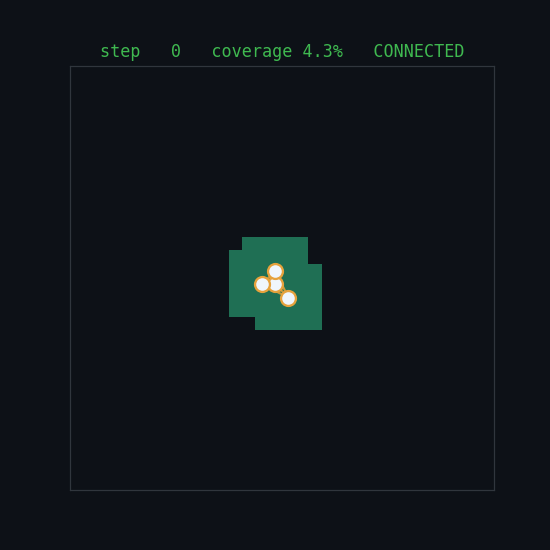

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib import colors
from IPython.display import Image

def rollout_frames(cfg, dev, policy_fn, max_steps=None):
    e = SwarmEnv(cfg, dev); obs = e.observe(); frames = []
    for t in range(max_steps or cfg.max_steps):
        frames.append({'pos': e.pos[0].cpu().numpy().copy(),
                       'visited': e.visited[0].cpu().numpy().copy(),
                       'adj': e._adjacency()[0].cpu().numpy(),
                       'cov': float(e.visited[0].float().mean()),
                       'conn': bool(e._connected(e._adjacency())[0]), 't': t})
        obs, r, d, info = e.step(policy_fn(obs))
        if bool(d[0]): break
    return frames

def animate(frames, cfg, path):
    G = cfg.grid_size; fig, ax = plt.subplots(figsize=(5,5), dpi=110)
    cmap = colors.ListedColormap(['#0d1117', '#1f6f54'])
    def draw(i):
        ax.clear(); f = frames[i]
        ax.imshow(f['visited'], cmap=cmap, vmin=0, vmax=1, origin='upper')
        pos, adj, N = f['pos'], f['adj'], f['pos'].shape[0]
        for u in range(N):
            for v in range(u+1, N):
                if adj[u, v]:
                    ax.plot([pos[u,1],pos[v,1]],[pos[u,0],pos[v,0]], color='#e6a23c', lw=1.4, alpha=0.85, zorder=2)
        ax.scatter(pos[:,1], pos[:,0], c='#f0f6fc', s=95, edgecolors='#e6a23c', linewidths=1.5, zorder=3)
        col = '#3fb950' if f['conn'] else '#f85149'
        ax.set_title('step %3d   coverage %.1f%%   %s' % (f['t'], 100*f['cov'],
                     'CONNECTED' if f['conn'] else 'DISCONNECTED'), color=col, fontsize=11, family='monospace')
        ax.set_xlim(-0.5, G-0.5); ax.set_ylim(G-0.5, -0.5); ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_color('#30363d')
        fig.patch.set_facecolor('#0d1117'); ax.set_facecolor('#0d1117')
    FuncAnimation(fig, draw, frames=len(frames), interval=110).save(path, writer=PillowWriter(fps=9))
    plt.close(fig)

# greedy (argmax) policy = smoother to watch than sampling
@torch.no_grad()
def greedy(obs): return torch.argmax(ac.actor(obs), dim=-1)

viz_cfg = Cfg(grid_size=32, n_agents=4, num_envs=1, max_steps=256,
              comm_radius=4, sense_radius=2)
frames = rollout_frames(viz_cfg, dev, greedy)
animate(frames, viz_cfg, 'swarm.gif')
print(f"{len(frames)} steps, final coverage {100*frames[-1]['cov']:.1f}%")
Image(filename='swarm.gif')

In [8]:
class ShapedEnv(SwarmEnv):
    """SwarmEnv + frontier-potential shaping: dense reward for moving the swarm
    centroid toward the nearest unexplored cell. Inert when frontier_scale=0."""
    def __init__(s, cfg, device):
        s._grid_rc = None
        super().__init__(cfg, device)
        g = cfg.grid_size
        rr, cc = torch.meshgrid(torch.arange(g, device=device),
                                torch.arange(g, device=device), indexing='ij')
        s._grid_rc = torch.stack([rr, cc], dim=-1).float()
        s._prev_phi = s._frontier_potential()

    def _frontier_potential(s):
        if s._grid_rc is None: return torch.zeros(s.B, device=s.device)
        cen = s.pos.float().mean(dim=1)                                  # swarm centroid
        d = ((s._grid_rc.unsqueeze(0) - cen.view(-1,1,1,2))**2).sum(-1).sqrt()
        d = d.masked_fill(s.visited, 1e6)                                # ignore covered
        dmin = d.view(s.B, -1).min(dim=1).values.clamp(max=s.cfg.grid_size*1.5)
        return -dmin / s.cfg.grid_size                                   # closer frontier -> higher

    def reset(s, mask):
        super().reset(mask)
        if s._grid_rc is not None: s._prev_phi = s._frontier_potential()

    def step(s, actions):
        obs, reward, done, info = super().step(actions)
        fs = getattr(s.cfg, 'frontier_scale', 0.0)
        if fs > 0 and s._grid_rc is not None:
            phi = s._frontier_potential()
            reward = reward + fs * (phi - s._prev_phi)
            s._prev_phi = phi
        return obs, reward, done, info

SwarmEnv = ShapedEnv   # existing train/render cells now use shaping when frontier_scale>0

In [9]:
import shutil; shutil.rmtree(CKPT_DIR, ignore_errors=True); os.makedirs(CKPT_DIR, exist_ok=True)

cfg = Cfg(grid_size=32, n_agents=6, num_envs=4096, max_steps=256,
          comm_radius=4, sense_radius=2,
          coverage_reward_scale=8.0, frontier_scale=4.0)   # <-- 6 agents + frontier shaping
ac, hist = train_scaled(cfg, dev, total_updates=400, T=64, ckpt_every=25,
                        cr_start=12, cr_warm_frac=0.4)

upd    0  cr=12  coverage 0.180  389,233 env-steps/s
upd    5  cr=12  coverage 0.379  375,441 env-steps/s
upd   10  cr=12  coverage 0.331  368,328 env-steps/s
upd   15  cr=11  coverage 0.374  372,912 env-steps/s
upd   20  cr=11  coverage 0.441  374,894 env-steps/s
upd   25  cr=11  coverage 0.402  374,864 env-steps/s
upd   30  cr=10  coverage 0.388  368,378 env-steps/s
upd   35  cr=10  coverage 0.389  371,433 env-steps/s
upd   40  cr=10  coverage 0.458  374,819 env-steps/s
upd   45  cr=10  coverage 0.484  371,417 env-steps/s
upd   50  cr=10  coverage 0.545  372,599 env-steps/s
upd   55  cr=9  coverage 0.484  375,499 env-steps/s
upd   60  cr=9  coverage 0.504  370,832 env-steps/s
upd   65  cr=9  coverage 0.510  367,971 env-steps/s
upd   70  cr=8  coverage 0.495  370,678 env-steps/s
upd   75  cr=8  coverage 0.490  378,931 env-steps/s
upd   80  cr=8  coverage 0.497  369,867 env-steps/s
upd   85  cr=8  coverage 0.516  369,297 env-steps/s
upd   90  cr=8  coverage 0.527  374,547 env-steps/s
u

256 steps, final coverage 49.0%


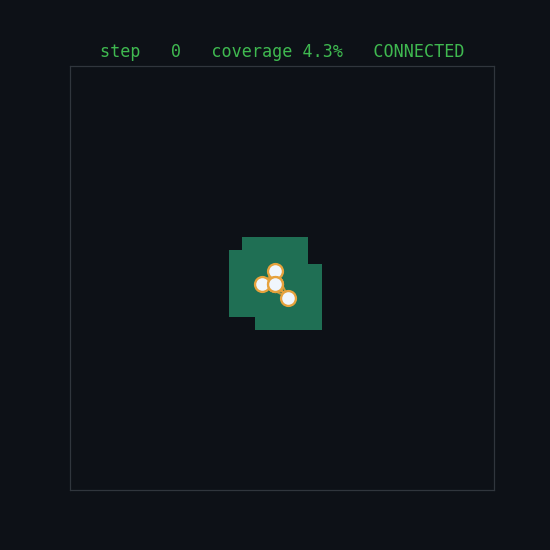

In [10]:
viz_cfg = Cfg(grid_size=32, n_agents=6, num_envs=1, max_steps=256,
              comm_radius=4, sense_radius=2)
frames = rollout_frames(viz_cfg, dev, greedy)
animate(frames, viz_cfg, 'swarm.gif')
print(f"{len(frames)} steps, final coverage {100*frames[-1]['cov']:.1f}%")
Image(filename='swarm.gif')

In [11]:
import json, math

FORMATIONS = ["line", "column", "wedge", "diamond", "cluster"]
FAILURE_SCENARIOS = ["broken_single","broken_double","rogue_single","rogue_double",
    "rogue_coordinated","comms_jam","sensor_spoof","actuator_bias","intermittent",
    "delayed_action","progressive_ramp","edge_drift"]
STAY,UP,DOWN,LEFT,RIGHT = 0,1,2,3,4

def formation_starts(name, n, g, spacing=2):
    c=g//2; s=max(1,min(spacing,2))
    clip=lambda p:[max(0,min(g-1,p[0])),max(0,min(g-1,p[1]))]
    if name=="line":    pts=[(c,c-(n-1)*s//2+i*s) for i in range(n)]
    elif name=="column":pts=[(c-(n-1)*s//2+i*s,c) for i in range(n)]
    elif name=="wedge":
        pts=[(c-s,c)]; side=1
        for i in range(1,n):
            r=(i+1)//2; pts.append((c-s+r*s,c+side*r*s)); side*=-1
        pts=pts[:n]
    elif name=="diamond":
        pts=[(c+round(s*math.cos(2*math.pi*i/n)),c+round(s*math.sin(2*math.pi*i/n))) for i in range(n)]
    elif name=="cluster":
        pts=[(c,c)]; ring=1
        while len(pts)<n:
            for dr in range(-ring,ring+1):
                for dc in range(-ring,ring+1):
                    if max(abs(dr),abs(dc))==ring and len(pts)<n: pts.append((c+dr,c+dc))
            ring+=1
    return [clip(p) for p in pts]

class Applier:
    """Injects one failure scenario into a batch of missions during rollout."""
    def __init__(s,name):
        s.name=name; s.degraded=(name!="nominal")
        s.n_affected={"broken_double":2,"rogue_double":2,"rogue_coordinated":2,"comms_jam":2}.get(
            name, 0 if name=="nominal" else 1)
    def reset(s,env):
        B,N=env.B,env.N
        if s.n_affected<=0: s.aff=torch.zeros(B,N,dtype=torch.bool,device=env.device)
        else:
            sc=torch.rand(B,N,generator=env.gen,device=env.device)
            top=sc.topk(min(s.n_affected,N),dim=1).indices
            s.aff=torch.zeros(B,N,dtype=torch.bool,device=env.device); s.aff.scatter_(1,top,True)
        s.prev=torch.zeros(B,N,dtype=torch.long,device=env.device)
    def corrupt_obs(s,obs,env):
        if s.name!="sensor_spoof": return obs
        p=env.cfg.obs_window**2; o=obs.clone()
        o[...,:p]=torch.where(s.aff.unsqueeze(-1),torch.zeros_like(o[...,:p]),o[...,:p]); return o
    def override(s,a,env,t):
        n=a.clone(); dev=torch.zeros(env.B,device=env.device)
        if s.name in("broken_single","broken_double"):
            n=torch.where(s.aff,torch.full_like(a,STAY),a); dev=s.aff.float().sum(1)
        elif s.name in("rogue_single","rogue_double"):
            r=torch.randint(0,5,a.shape,generator=env.gen,device=env.device)
            n=torch.where(s.aff,r,a); dev=s.aff.float().sum(1)
        elif s.name=="rogue_coordinated":
            f=torch.where((env.t%2==0).unsqueeze(1),torch.full_like(a,UP),torch.full_like(a,LEFT))
            n=torch.where(s.aff,f,a); dev=s.aff.float().sum(1)
        elif s.name=="actuator_bias":
            sel=s.aff&(a!=STAY); n=torch.where(sel,torch.full_like(a,RIGHT),a); dev=sel.float().sum(1)
        elif s.name=="intermittent":
            drop=torch.rand(a.shape,generator=env.gen,device=env.device)<0.4
            sel=s.aff&drop; n=torch.where(sel,torch.full_like(a,STAY),a); dev=sel.float().sum(1)
        elif s.name=="delayed_action":
            n=torch.where(s.aff,s.prev,a); s.prev=a.clone(); dev=s.aff.float().sum(1)
        elif s.name=="progressive_ramp":
            frac=(env.t.float()/env.cfg.max_steps).unsqueeze(1)
            fire=torch.rand(a.shape,generator=env.gen,device=env.device)<frac
            r=torch.randint(0,5,a.shape,generator=env.gen,device=env.device)
            sel=s.aff&fire; n=torch.where(sel,r,a); dev=sel.float().sum(1)
        elif s.name=="edge_drift":
            g=env.cfg.grid_size; up=env.pos[...,0]<=(g-1-env.pos[...,0])
            f=torch.where(up,torch.full_like(a,UP),torch.full_like(a,DOWN))
            n=torch.where(s.aff,f,a); dev=s.aff.float().sum(1)
        return n,dev   # nominal / comms_jam / sensor_spoof don't override actions

In [12]:
@torch.no_grad()
def generate_corpus(ac, base_cfg, dev, n_per_cell=50,
                    out_path="/content/drive/MyDrive/swarm_rl/corpus.jsonl", store_positions=True):
    scenarios=["nominal"]+FAILURE_SCENARIOS
    greedy_fn=lambda o: torch.argmax(ac.actor(o),dim=-1)
    n=0
    with open(out_path,"w") as fh:
        for form in FORMATIONS:
            starts=torch.tensor(formation_starts(form,base_cfg.n_agents,base_cfg.grid_size),
                                dtype=torch.long,device=dev)
            for scen in scenarios:
                cfg=Cfg(**dict(base_cfg.__dict__)); cfg.num_envs=n_per_cell
                if scen=="comms_jam": cfg.comm_radius=max(1,base_cfg.comm_radius//2)
                e=SwarmEnv(cfg,dev); e.base=starts
                e.reset(torch.ones(cfg.num_envs,dtype=torch.bool,device=dev))
                app=Applier(scen); app.reset(e)
                T,B,N=cfg.max_steps,cfg.num_envs,cfg.n_agents
                pos_t=torch.zeros(T,B,N,2,dtype=torch.int16,device=dev)
                conn_t=torch.zeros(T,B,dtype=torch.bool,device=dev)
                deg_t=torch.zeros(T,B,device=dev); cov_t=torch.zeros(T,B,device=dev); dev_t=torch.zeros(T,B,device=dev)
                tbreak=torch.full((B,),-1,dtype=torch.long,device=dev); obs=e.observe()
                for t in range(T):
                    adj=e._adjacency(); deg=adj.float().sum(-1).mean(-1)-1
                    pos_t[t]=e.pos.to(torch.int16); conn_t[t]=e._connected(adj)
                    deg_t[t]=deg; cov_t[t]=e.visited.float().mean(dim=(1,2))
                    a,ndev=app.override(greedy_fn(app.corrupt_obs(obs,e)),e,t); dev_t[t]=ndev
                    obs,r,d,info=e.step(a)
                    nb=(~info['connected'])&(tbreak<0); tbreak[nb]=t
                pc,cc,dc,vc,ec,tb=[x.cpu() for x in (pos_t,conn_t,deg_t,cov_t,dev_t,tbreak)]
                for b in range(B):
                    end=int(tb[b])+1 if tb[b]>=0 else T
                    rec={"formation":form,"scenario":scen,"degraded":app.degraded,
                         "n_affected":int(app.n_affected),"n_agents":N,"grid":cfg.grid_size,
                         "t_break":(int(tb[b]) if tb[b]>=0 else None),"horizon":T,
                         "final_coverage":round(float(vc[end-1,b]),4),
                         "connected":cc[:end,b].int().tolist(),
                         "avg_degree":[round(x,3) for x in dc[:end,b].tolist()],
                         "coverage":[round(x,4) for x in vc[:end,b].tolist()],
                         "n_deviating":ec[:end,b].int().tolist()}
                    if store_positions: rec["positions"]=pc[:end,b].tolist()
                    fh.write(json.dumps(rec)+"\n"); n+=1
    return n, out_path

base = Cfg(grid_size=32, n_agents=6, max_steps=256, comm_radius=4, sense_radius=2)
n, path = generate_corpus(ac, base, dev, n_per_cell=50)

# summary — the nominal-vs-degraded separation is the signal
import json as J
recs=[J.loads(l) for l in open(path)]
nom=[r for r in recs if not r["degraded"]]; deg=[r for r in recs if r["degraded"]]
nom_survive=sum(1 for r in nom if r["t_break"] is None)/len(nom)
deg_break=[r["t_break"] for r in deg if r["t_break"] is not None]
print(f"wrote {n} missions -> {path}")
print(f"nominal: {len(nom)}  | survived to horizon: {100*nom_survive:.0f}%")
print(f"degraded: {len(deg)} | broke early: {len(deg_break)} ({100*len(deg_break)/len(deg):.0f}%), mean t_break {sum(deg_break)/max(1,len(deg_break)):.0f}")

wrote 3250 missions -> /content/drive/MyDrive/swarm_rl/corpus.jsonl
nominal: 250  | survived to horizon: 50%
degraded: 3000 | broke early: 2830 (94%), mean t_break 13


In [13]:
class ShapedEnv(SwarmEnv):
    """SwarmEnv + frontier shaping + optional multi-formation training starts."""
    def __init__(s, cfg, device):
        s._grid_rc=None; s._bank=None
        super().__init__(cfg, device)
        g=cfg.grid_size
        rr,cc=torch.meshgrid(torch.arange(g,device=device),torch.arange(g,device=device),indexing='ij')
        s._grid_rc=torch.stack([rr,cc],dim=-1).float()
        bank=getattr(cfg,'formation_bank',None)
        if bank is not None: s.set_formation_bank(bank)
        s._prev_phi=s._frontier_potential()

    def _frontier_potential(s):
        if s._grid_rc is None: return torch.zeros(s.B, device=s.device)
        cen=s.pos.float().mean(dim=1)
        d=((s._grid_rc.unsqueeze(0)-cen.view(-1,1,1,2))**2).sum(-1).sqrt()
        d=d.masked_fill(s.visited, 1e6)
        dmin=d.view(s.B,-1).min(dim=1).values.clamp(max=s.cfg.grid_size*1.5)
        return -dmin/s.cfg.grid_size

    def set_formation_bank(s, start_lists):
        s._bank=torch.tensor(start_lists,dtype=torch.long,device=s.device)   # (F,N,2)
        s.reset(torch.ones(s.B,dtype=torch.bool,device=s.device))

    def reset(s, mask):
        if getattr(s,'_bank',None) is not None:
            g=s.cfg.grid_size; idx=mask.nonzero(as_tuple=False).squeeze(-1)
            if idx.numel()>0:
                b=idx.numel()
                fsel=torch.randint(0,s._bank.shape[0],(b,),generator=s.gen,device=s.device)
                jit=torch.randint(-1,2,(b,1,2),generator=s.gen,device=s.device)
                st=(s._bank[fsel]+jit).clamp(0,g-1)
                s.pos[idx]=st; s.visited[idx]=False; s.t[idx]=0; s.ep_len[idx]=0.0
                s._cover(idx)
        else:
            super().reset(mask)
        if s._grid_rc is not None: s._prev_phi=s._frontier_potential()

    def step(s, actions):
        obs,reward,done,info=super().step(actions)
        fs=getattr(s.cfg,'frontier_scale',0.0)
        if fs>0 and s._grid_rc is not None:
            phi=s._frontier_potential(); reward=reward+fs*(phi-s._prev_phi); s._prev_phi=phi
        return obs,reward,done,info

SwarmEnv = ShapedEnv

In [14]:
class Applier:
    def __init__(s,name):
        s.name=name; s.degraded=(name!="nominal")
        s.n_affected={"broken_double":2,"rogue_double":2,"rogue_coordinated":2,"comms_jam":2}.get(
            name, 0 if name=="nominal" else 1)
    def reset(s,env):
        B,N=env.B,env.N
        if s.n_affected<=0: s.aff=torch.zeros(B,N,dtype=torch.bool,device=env.device)
        else:
            sc=torch.rand(B,N,generator=env.gen,device=env.device)
            top=sc.topk(min(s.n_affected,N),dim=1).indices
            s.aff=torch.zeros(B,N,dtype=torch.bool,device=env.device); s.aff.scatter_(1,top,True)
        s.prev=torch.zeros(B,N,dtype=torch.long,device=env.device)
        hi=max(21,env.cfg.max_steps//2)
        s.onset=torch.randint(20,hi,(B,),generator=env.gen,device=env.device)   # <-- delayed onset
    def corrupt_obs(s,obs,env):
        if s.name!="sensor_spoof": return obs
        active=(env.t>=s.onset).unsqueeze(1)                                     # <-- gated by onset
        p=env.cfg.obs_window**2; o=obs.clone(); m=(s.aff&active).unsqueeze(-1)
        o[...,:p]=torch.where(m,torch.zeros_like(o[...,:p]),o[...,:p]); return o
    def override(s,a,env,t):
        n=a.clone(); dev=torch.zeros(env.B,device=env.device)
        if s.name in("broken_single","broken_double"):
            n=torch.where(s.aff,torch.full_like(a,STAY),a); dev=s.aff.float().sum(1)
        elif s.name in("rogue_single","rogue_double"):
            r=torch.randint(0,5,a.shape,generator=env.gen,device=env.device)
            n=torch.where(s.aff,r,a); dev=s.aff.float().sum(1)
        elif s.name=="rogue_coordinated":
            f=torch.where((env.t%2==0).unsqueeze(1),torch.full_like(a,UP),torch.full_like(a,LEFT))
            n=torch.where(s.aff,f,a); dev=s.aff.float().sum(1)
        elif s.name=="actuator_bias":
            sel=s.aff&(a!=STAY); n=torch.where(sel,torch.full_like(a,RIGHT),a); dev=sel.float().sum(1)
        elif s.name=="intermittent":
            drop=torch.rand(a.shape,generator=env.gen,device=env.device)<0.4
            sel=s.aff&drop; n=torch.where(sel,torch.full_like(a,STAY),a); dev=sel.float().sum(1)
        elif s.name=="delayed_action":
            n=torch.where(s.aff,s.prev,a); s.prev=a.clone(); dev=s.aff.float().sum(1)
        elif s.name=="progressive_ramp":
            frac=(env.t.float()/env.cfg.max_steps).unsqueeze(1)
            fire=torch.rand(a.shape,generator=env.gen,device=env.device)<frac
            r=torch.randint(0,5,a.shape,generator=env.gen,device=env.device)
            sel=s.aff&fire; n=torch.where(sel,r,a); dev=sel.float().sum(1)
        elif s.name=="edge_drift":
            g=env.cfg.grid_size; up=env.pos[...,0]<=(g-1-env.pos[...,0])
            f=torch.where(up,torch.full_like(a,UP),torch.full_like(a,DOWN))
            n=torch.where(s.aff,f,a); dev=s.aff.float().sum(1)
        active=(env.t>=s.onset)                                                  # <-- gate all overrides
        n=torch.where(active.unsqueeze(1),n,a); dev=dev*active.float()
        return n,dev

In [15]:
import shutil; shutil.rmtree(CKPT_DIR, ignore_errors=True); os.makedirs(CKPT_DIR, exist_ok=True)

cfg = Cfg(grid_size=32, n_agents=6, num_envs=4096, max_steps=256,
          comm_radius=4, sense_radius=2, coverage_reward_scale=8.0, frontier_scale=4.0)
cfg.formation_bank = [formation_starts(f, cfg.n_agents, cfg.grid_size) for f in FORMATIONS]  # <-- train on all 5
ac, hist = train_scaled(cfg, dev, total_updates=400, T=64, ckpt_every=25, cr_start=12, cr_warm_frac=0.4)

upd    0  cr=12  coverage 0.212  360,920 env-steps/s
upd    5  cr=12  coverage 0.368  353,303 env-steps/s
upd   10  cr=12  coverage 0.389  358,614 env-steps/s
upd   15  cr=11  coverage 0.419  357,855 env-steps/s
upd   20  cr=11  coverage 0.451  349,669 env-steps/s
upd   25  cr=11  coverage 0.477  361,396 env-steps/s
upd   30  cr=10  coverage 0.465  361,506 env-steps/s
upd   35  cr=10  coverage 0.448  355,608 env-steps/s
upd   40  cr=10  coverage 0.460  356,596 env-steps/s
upd   45  cr=10  coverage 0.481  359,593 env-steps/s
upd   50  cr=10  coverage 0.498  361,553 env-steps/s
upd   55  cr=9  coverage 0.495  355,833 env-steps/s
upd   60  cr=9  coverage 0.497  355,867 env-steps/s
upd   65  cr=9  coverage 0.522  349,319 env-steps/s
upd   70  cr=8  coverage 0.505  357,739 env-steps/s
upd   75  cr=8  coverage 0.495  360,449 env-steps/s
upd   80  cr=8  coverage 0.505  360,313 env-steps/s
upd   85  cr=8  coverage 0.517  356,750 env-steps/s
upd   90  cr=8  coverage 0.518  353,677 env-steps/s
u

In [16]:
@torch.no_grad()
def generate_corpus(ac, base_cfg, dev, n_per_cell=50,
                    out_path="/content/drive/MyDrive/swarm_rl/corpus.jsonl", store_positions=True):
    scenarios = ["nominal"] + FAILURE_SCENARIOS
    greedy_fn = lambda o: torch.argmax(ac.actor(o), dim=-1)
    n = 0
    with open(out_path, "w") as fh:
        for form in FORMATIONS:
            starts = torch.tensor(formation_starts(form, base_cfg.n_agents, base_cfg.grid_size),
                                  dtype=torch.long, device=dev)
            for scen in scenarios:
                cfg = Cfg(**dict(base_cfg.__dict__)); cfg.num_envs = n_per_cell
                if scen == "comms_jam": cfg.comm_radius = max(1, base_cfg.comm_radius // 2)
                e = SwarmEnv(cfg, dev); e.base = starts
                e.reset(torch.ones(cfg.num_envs, dtype=torch.bool, device=dev))
                app = Applier(scen); app.reset(e)
                T, B, N = cfg.max_steps, cfg.num_envs, cfg.n_agents
                pos_t = torch.zeros(T, B, N, 2, dtype=torch.int16, device=dev)
                conn_t = torch.zeros(T, B, dtype=torch.bool, device=dev)
                deg_t = torch.zeros(T, B, device=dev); cov_t = torch.zeros(T, B, device=dev); dev_t = torch.zeros(T, B, device=dev)
                tbreak = torch.full((B,), -1, dtype=torch.long, device=dev); obs = e.observe()
                for t in range(T):
                    adj = e._adjacency(); deg = adj.float().sum(-1).mean(-1) - 1
                    pos_t[t] = e.pos.to(torch.int16); conn_t[t] = e._connected(adj)
                    deg_t[t] = deg; cov_t[t] = e.visited.float().mean(dim=(1, 2))
                    a, ndev = app.override(greedy_fn(app.corrupt_obs(obs, e)), e, t); dev_t[t] = ndev
                    obs, r, d, info = e.step(a)
                    nb = (~info['connected']) & (tbreak < 0); tbreak[nb] = t
                pc, cc, dc, vc, ec, tb = [x.cpu() for x in (pos_t, conn_t, deg_t, cov_t, dev_t, tbreak)]
                for b in range(B):
                    end = int(tb[b]) + 1 if tb[b] >= 0 else T
                    rec = {"formation": form, "scenario": scen, "degraded": app.degraded,
                           "n_affected": int(app.n_affected), "n_agents": N, "grid": cfg.grid_size,
                           "t_break": (int(tb[b]) if tb[b] >= 0 else None), "horizon": T,
                           "final_coverage": round(float(vc[end-1, b]), 4),
                           "connected": cc[:end, b].int().tolist(),
                           "avg_degree": [round(x, 3) for x in dc[:end, b].tolist()],
                           "coverage": [round(x, 4) for x in vc[:end, b].tolist()],
                           "n_deviating": ec[:end, b].int().tolist()}
                    if store_positions: rec["positions"] = pc[:end, b].tolist()
                    fh.write(json.dumps(rec) + "\n"); n += 1
    return n, out_path

base = Cfg(grid_size=32, n_agents=6, max_steps=256, comm_radius=4, sense_radius=2)
n, path = generate_corpus(ac, base, dev, n_per_cell=50)

# summary — the nominal-vs-degraded separation is the signal
import json as J
recs = [J.loads(l) for l in open(path)]
nom = [r for r in recs if not r["degraded"]]; deg = [r for r in recs if r["degraded"]]
nom_survive = sum(1 for r in nom if r["t_break"] is None) / len(nom)
deg_break = [r["t_break"] for r in deg if r["t_break"] is not None]
print(f"wrote {n} missions -> {path}")
print(f"nominal: {len(nom)}  | survived to horizon: {100*nom_survive:.0f}%")
print(f"degraded: {len(deg)} | broke early: {len(deg_break)} ({100*len(deg_break)/len(deg):.0f}%), mean t_break {sum(deg_break)/max(1,len(deg_break)):.0f}")

wrote 3250 missions -> /content/drive/MyDrive/swarm_rl/corpus.jsonl
nominal: 250  | survived to horizon: 100%
degraded: 3000 | broke early: 1471 (49%), mean t_break 62


In [17]:
# ============================================================
#  Interactive swarm simulator (self-contained, runs in Colab)
#  play / pause / step / reset · sliders · formation & failure pickers
#  Pick a Failure scenario to watch the swarm fracture: stretched comm
#  links redden, the broken edge flashes, stranded agents pulse red,
#  and the graph splits into colour-separated components.
#  Defaults to the heuristic controller; bakes in your trained `ac` if present.
# ============================================================
import json
from IPython.display import HTML, display

SIM_HTML = r'''<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Connected-Coverage Swarm — Simulator</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
<link href="https://fonts.googleapis.com/css2?family=DM+Mono:wght@400;500&family=DM+Sans:opsz,wght@9..40,400;9..40,500;9..40,600&family=Fraunces:opsz,wght@9..144,400;9..144,500&display=swap" rel="stylesheet">
<style>
  :root{
    --bg:#0a0d12; --panel:#10151c; --panel2:#161d26; --grid:#0c1016; --line:#1d242e;
    --cover:#1f6f54; --cover-hi:#34a074; --agent:#f4f7fb; --edge:#e6a23c;
    --alert:#f85149; --ok:#46c168; --text:#c4ced8; --muted:#76838f; --accent:#34a074;
  }
  *{box-sizing:border-box}
  html,body{margin:0;background:var(--bg);color:var(--text);
    font-family:'DM Sans',system-ui,sans-serif;-webkit-font-smoothing:antialiased}
  .wrap{max-width:1060px;margin:0 auto;padding:32px 22px 60px}
  header{display:flex;justify-content:space-between;align-items:flex-end;
    gap:16px;flex-wrap:wrap;border-bottom:1px solid var(--line);padding-bottom:18px;margin-bottom:24px}
  h1{font-family:'Fraunces',serif;font-weight:500;font-size:26px;line-height:1.05;margin:0;color:#eef3f8;letter-spacing:.2px}
  .sub{font-family:'DM Mono',monospace;font-size:11.5px;color:var(--muted);
    text-transform:uppercase;letter-spacing:.16em;margin-top:7px}
  .badge{font-family:'DM Mono',monospace;font-size:11px;color:var(--muted);
    border:1px solid var(--line);border-radius:2px;padding:6px 10px;white-space:nowrap}
  .stage{display:grid;grid-template-columns:minmax(0,1fr) 268px;gap:22px;align-items:start}
  @media(max-width:760px){.stage{grid-template-columns:1fr}}
  .canvasCard{background:var(--panel);border:1px solid var(--line);border-radius:6px;padding:14px}
  .canvasCard canvas{width:100%;height:auto;display:block;border-radius:3px;background:var(--grid)}
  .readout{display:flex;gap:0;margin-top:13px;border:1px solid var(--line);border-radius:4px;overflow:hidden}
  .readout div{flex:1;padding:9px 10px;border-right:1px solid var(--line)}
  .readout div:last-child{border-right:none}
  .readout .k{font-family:'DM Mono',monospace;font-size:9.5px;letter-spacing:.13em;
    text-transform:uppercase;color:var(--muted)}
  .readout .v{font-family:'DM Mono',monospace;font-size:17px;margin-top:3px;color:#e9eef4}
  .v.ok{color:var(--ok)} .v.bad{color:var(--alert)}
  .transport{display:flex;gap:8px;margin-top:13px;align-items:center;flex-wrap:wrap}
  button.t{font-family:'DM Mono',monospace;font-size:12.5px;letter-spacing:.04em;
    background:var(--panel2);color:var(--text);border:1px solid var(--line);
    border-radius:4px;padding:9px 15px;cursor:pointer;transition:.13s}
  button.t:hover{border-color:var(--accent);color:#eef3f8}
  button.t.primary{background:var(--accent);color:#06130d;border-color:var(--accent);font-weight:500}
  button.t.primary:hover{background:var(--cover-hi)}
  .panel{background:var(--panel);border:1px solid var(--line);border-radius:6px;padding:4px 16px 16px}
  .grp{padding:14px 0;border-bottom:1px solid var(--line)}
  .grp:last-child{border-bottom:none}
  .grp h3{font-family:'DM Mono',monospace;font-size:10px;letter-spacing:.15em;
    text-transform:uppercase;color:var(--muted);margin:0 0 12px}
  label.row{display:flex;justify-content:space-between;align-items:center;margin:11px 0;
    font-family:'DM Mono',monospace;font-size:12px;color:var(--text)}
  label.row .val{color:var(--accent)}
  input[type=range]{-webkit-appearance:none;width:100%;height:3px;background:var(--line);
    border-radius:3px;margin:9px 0 2px;outline:none}
  input[type=range]::-webkit-slider-thumb{-webkit-appearance:none;width:13px;height:13px;
    border-radius:50%;background:var(--accent);cursor:pointer;border:2px solid var(--panel)}
  input[type=range]::-moz-range-thumb{width:13px;height:13px;border-radius:50%;
    background:var(--accent);cursor:pointer;border:2px solid var(--panel)}
  select{width:100%;font-family:'DM Mono',monospace;font-size:12px;color:var(--text);
    background:var(--panel2);border:1px solid var(--line);border-radius:4px;padding:8px 9px;
    margin-top:5px;cursor:pointer;outline:none}
  select:focus{border-color:var(--accent)}
  .field{margin:11px 0}
  .field .lab{font-family:'DM Mono',monospace;font-size:11px;color:var(--muted)}
  .loadrow{display:flex;gap:7px;align-items:center;margin-top:6px}
  .loadrow label.file{flex:1;font-family:'DM Mono',monospace;font-size:11px;text-align:center;
    background:var(--panel2);border:1px dashed var(--line);border-radius:4px;padding:8px;cursor:pointer;color:var(--muted)}
  .loadrow label.file:hover{border-color:var(--accent);color:var(--text)}
  .note{font-family:'DM Mono',monospace;font-size:10.5px;color:var(--muted);line-height:1.5;margin-top:8px}
  .ctrl-state{font-family:'DM Mono',monospace;font-size:11px;color:var(--accent);margin-top:7px}
  footer{margin-top:30px;font-family:'DM Mono',monospace;font-size:10.5px;color:var(--muted);
    line-height:1.7;border-top:1px solid var(--line);padding-top:16px}
  .legend{display:flex;gap:16px;flex-wrap:wrap;margin-top:11px;font-family:'DM Mono',monospace;font-size:10.5px;color:var(--muted)}
  .legend span{display:inline-flex;align-items:center;gap:6px}
  .dot{width:9px;height:9px;border-radius:50%;display:inline-block}
</style>
</head>
<body>
<div class="wrap">
  <header>
    <div>
      <h1>Connected-Coverage Swarm</h1>
      <div class="sub">multi-agent RL environment · live simulator</div>
    </div>
    <div class="badge" id="banner">connected · mission live</div>
  </header>

  <div class="stage">
    <div class="canvasCard">
      <canvas id="cv" width="560" height="560"></canvas>
      <div class="readout">
        <div><div class="k">step</div><div class="v" id="r-step">0</div></div>
        <div><div class="k">coverage</div><div class="v" id="r-cov">0%</div></div>
        <div><div class="k">link state</div><div class="v ok" id="r-conn">connected</div></div>
        <div><div class="k">deviating</div><div class="v" id="r-dev">0</div></div>
      </div>
      <div class="transport">
        <button class="t primary" id="btn-play">▶ Play</button>
        <button class="t" id="btn-step">Step</button>
        <button class="t" id="btn-reset">Reset</button>
        <span style="flex:1"></span>
        <span class="note" id="ctrl-tag">controller · heuristic</span>
      </div>
      <div class="legend">
        <span><i class="dot" style="background:var(--cover)"></i>covered</span>
        <span><i class="dot" style="background:var(--agent)"></i>agent</span>
        <span><i class="dot" style="background:var(--edge)"></i>comm link</span>
        <span><i class="dot" style="background:var(--alert)"></i>affected agent</span>
      </div>
    </div>

    <div class="panel">
      <div class="grp">
        <h3>Swarm</h3>
        <label class="row">Agents <span class="val" id="v-agents">6</span></label>
        <input type="range" id="s-agents" min="2" max="10" step="1" value="6">
        <label class="row">Comm radius <span class="val" id="v-cr">4</span></label>
        <input type="range" id="s-cr" min="2" max="8" step="1" value="4">
        <label class="row">Sense radius <span class="val" id="v-sr">2</span></label>
        <input type="range" id="s-sr" min="1" max="3" step="1" value="2">
      </div>
      <div class="grp">
        <h3>Mission</h3>
        <div class="field"><div class="lab">Formation</div>
          <select id="sel-form">
            <option value="cluster">cluster</option><option value="line">line</option>
            <option value="column">column</option><option value="wedge">wedge</option>
            <option value="diamond">diamond</option>
          </select></div>
        <div class="field"><div class="lab">Failure scenario</div>
          <select id="sel-scen">
            <option value="nominal">nominal (no failure)</option>
            <option value="broken_single">broken × 1</option>
            <option value="broken_double">broken × 2</option>
            <option value="rogue_single">rogue × 1</option>
            <option value="rogue_double">rogue × 2</option>
            <option value="rogue_coordinated">coordinated rogue</option>
            <option value="comms_jam">comms jam</option>
            <option value="sensor_spoof">sensor spoof</option>
            <option value="actuator_bias">actuator bias</option>
            <option value="intermittent">intermittent dropout</option>
            <option value="delayed_action">delayed action</option>
            <option value="progressive_ramp">progressive ramp</option>
            <option value="edge_drift">edge drift</option>
          </select></div>
      </div>
      <div class="grp">
        <h3>Playback</h3>
        <label class="row">Speed <span class="val" id="v-speed">6×</span></label>
        <input type="range" id="s-speed" min="1" max="20" step="1" value="6">
      </div>
      <div class="grp">
        <h3>Controller</h3>
        <div class="field"><div class="lab">Policy</div>
          <select id="sel-ctrl">
            <option value="heuristic">heuristic (frontier + cohesion)</option>
            <option value="trained" disabled>trained policy (load below)</option>
          </select></div>
        <div class="loadrow">
          <label class="file">load policy.json<input type="file" id="file-pol" accept=".json" hidden></label>
        </div>
        <div class="ctrl-state" id="pol-state"></div>
        <div class="note">Export from Colab: <br>actor weights → policy.json, then load to drive the swarm with your trained MAPPO net.</div>
      </div>
    </div>
  </div>

  <footer>
    32×32 grid · Chebyshev comm graph · hard connectivity constraint · failures inject after a random onset, exactly as in the training environment.<br>
    Coverage is the fraction of cells sensed; a mission fails the instant the communication graph disconnects.
  </footer>
</div>

<script>
const A = {STAY:0,UP:1,DOWN:2,LEFT:3,RIGHT:4};
const DR=[0,-1,1,0,0], DC=[0,0,0,-1,1];

const cfg = {G:32, N:6, cr:4, sr:2, W:7, horizon:256};
const cv = document.getElementById('cv');
const ctx = cv.getContext('2d');

// ---------- environment ----------
let pos, visited, t, firstBreak, affected, onset, controller='heuristic', mlp=null, jamFactor=1, scen='nominal';

function clip(v,hi){return v<0?0:(v>hi?hi:v);}
function centroid(){let r=0,c=0;for(const p of pos){r+=p[0];c+=p[1];}return [r/pos.length,c/pos.length];}

function formationStarts(name,n,G){
  const c=Math.floor(G/2), s=2, pts=[];
  if(name==='line')   for(let i=0;i<n;i++) pts.push([c, c-((n-1)*s>>1)+i*s]);
  else if(name==='column') for(let i=0;i<n;i++) pts.push([c-((n-1)*s>>1)+i*s, c]);
  else if(name==='wedge'){pts.push([c-s,c]);let side=1;for(let i=1;i<n;i++){const r=(i+1)>>1;pts.push([c-s+r*s,c+side*r*s]);side*=-1;}}
  else if(name==='diamond') for(let i=0;i<n;i++) pts.push([c+Math.round(s*Math.cos(2*Math.PI*i/n)), c+Math.round(s*Math.sin(2*Math.PI*i/n))]);
  else {pts.push([c,c]);let ring=1;while(pts.length<n){for(let dr=-ring;dr<=ring;dr++)for(let dc=-ring;dc<=ring;dc++){if(Math.max(Math.abs(dr),Math.abs(dc))===ring&&pts.length<n)pts.push([c+dr,c+dc]);}ring++;}}
  return pts.map(p=>[clip(p[0],G-1),clip(p[1],G-1)]);
}

function cover(){
  for(const [r,c] of pos)
    for(let dr=-cfg.sr;dr<=cfg.sr;dr++)
      for(let dc=-cfg.sr;dc<=cfg.sr;dc++)
        visited[clip(r+dr,cfg.G-1)*cfg.G + clip(c+dc,cfg.G-1)]=1;
}
function coverageFrac(){let s=0;for(let i=0;i<visited.length;i++)s+=visited[i];return s/visited.length;}

function commR(){return Math.max(1, scen==='comms_jam'? (cfg.cr*0.5)|0 : cfg.cr);}
function adjacency(){
  const n=pos.length, R=commR(), adj=[];
  for(let i=0;i<n;i++){adj.push([]);for(let j=0;j<n;j++){
    const d=Math.max(Math.abs(pos[i][0]-pos[j][0]),Math.abs(pos[i][1]-pos[j][1]));
    adj[i].push(i===j||d<=R?1:0);
  }}
  return adj;
}
function connected(adj){
  const n=adj.length, seen=new Array(n).fill(false), stack=[0]; seen[0]=true; let cnt=1;
  while(stack.length){const u=stack.pop();for(let v=0;v<n;v++) if(adj[u][v]&&!seen[v]){seen[v]=true;cnt++;stack.push(v);}}
  return cnt===n;
}
function avgDegree(adj){let s=0;for(let i=0;i<adj.length;i++){let d=-1;for(let j=0;j<adj.length;j++)d+=adj[i][j];s+=d;}return s/adj.length;}

function reset(){
  cfg.N=+s_agents.value; cfg.cr=+s_cr.value; cfg.sr=+s_sr.value; scen=sel_scen.value;
  const starts=formationStarts(sel_form.value,cfg.N,cfg.G);
  pos=starts.map(p=>p.slice());
  visited=new Uint8Array(cfg.G*cfg.G);
  t=0; firstBreak=null;
  // affected agents + onset
  affected=new Array(cfg.N).fill(false);
  const nAff={broken_double:2,rogue_double:2,rogue_coordinated:2,comms_jam:2}[scen] ?? (scen==='nominal'?0:1);
  const order=[...Array(cfg.N).keys()].sort(()=>Math.random()-0.5);
  for(let i=0;i<nAff;i++) affected[order[i]]=true;
  onset=20+Math.floor(Math.random()*Math.max(1,(cfg.horizon/2-20)));
  prevAction=new Array(cfg.N).fill(A.STAY);
  groupTimer=0; prevAdj=null; trails=pos.map(p=>[[p[0],p[1]]]);
  cover(); draw(); updateReadout();
}

// ---------- observation (matches env.py) ----------
function observe(){
  const G=cfg.G, w=cfg.W, p=w>>1, R=commR(), gcov=coverageFrac();
  const out=[];
  for(let a=0;a<pos.length;a++){
    const [r,c]=pos[a], o=[];
    for(let dr=-p;dr<=p;dr++)for(let dc=-p;dc<=p;dc++){
      const rr=r+dr, cc=c+dc;
      o.push((rr>=0&&rr<G&&cc>=0&&cc<G)?visited[rr*G+cc]:0);
    }
    // sensor spoof blanks the affected agent's patch after onset
    if(scen==='sensor_spoof'&&affected[a]&&t>=onset) for(let k=0;k<w*w;k++) o[k]=0;
    let nb=0; for(let b=0;b<pos.length;b++) if(b!==a){
      const d=Math.max(Math.abs(r-pos[b][0]),Math.abs(c-pos[b][1])); if(d<=R) nb++;
    }
    o.push(r/(G-1), c/(G-1), nb/Math.max(1,pos.length-1), gcov);
    out.push(o);
  }
  return out;
}

// ---------- controllers ----------
function nearestFrontierDist(r,c){
  // cheap: scan for nearest unvisited (Chebyshev). Sampled stride for speed at high G.
  const G=cfg.G; let best=1e9;
  for(let i=0;i<G;i++)for(let j=0;j<G;j++) if(!visited[i*G+j]){
    const d=Math.max(Math.abs(i-r),Math.abs(j-c)); if(d<best) best=d;
  }
  return best===1e9?0:best;
}
// connectivity of an arbitrary set of positions (for the safety guard)
function connectedAt(P){
  const n=P.length,R=commR(),seen=new Array(n).fill(false),st=[0];seen[0]=true;let c=1;
  const ok=(i,j)=>Math.max(Math.abs(P[i][0]-P[j][0]),Math.abs(P[i][1]-P[j][1]))<=R;
  while(st.length){const u=st.pop();for(let v=0;v<n;v++) if(v!==u&&!seen[v]&&ok(u,v)){seen[v]=true;c++;st.push(v);}}
  return c===n;
}
let groupDir=A.STAY, groupTimer=0;
function heuristicActions(){
  const ct=centroid(), cy=Math.round(ct[0]), cx=Math.round(ct[1]), R=commR();
  // re-pick a shared drift direction toward the nearest frontier from the centroid
  if(groupTimer<=0){
    const base=nearestFrontierDist(cy,cx); let bestA=A.STAY, bestD=base;
    for(let k=1;k<5;k++){
      const nr=clip(cy+DR[k],cfg.G-1), nc=clip(cx+DC[k],cfg.G-1);
      const d=nearestFrontierDist(nr,nc); if(d<bestD){bestD=d;bestA=k;}
    }
    if(bestA===A.STAY) bestA=1+((Math.random()*4)|0);   // keep moving if frontier isn't adjacent
    groupDir=bestA; groupTimer=4+((Math.random()*4)|0);
  }
  groupTimer--;
  // all agents drift together (preserves the connected formation); a few take a
  // small in-range nudge for graph liveliness and extra coverage
  const acts=new Array(pos.length);
  for(let a=0;a<pos.length;a++){
    let act=groupDir;
    if(Math.random()<0.18){
      const k=1+((Math.random()*4)|0);
      const nr=clip(pos[a][0]+DR[k],cfg.G-1), nc=clip(pos[a][1]+DC[k],cfg.G-1);
      if(Math.max(Math.abs(nr-cy),Math.abs(nc-cx))<=R-1) act=k;
    }
    acts[a]=act;
  }
  // safety guard: if the move would disconnect, fall back to rigid group drift
  const tentative=acts.map((k,a)=>[clip(pos[a][0]+DR[k],cfg.G-1),clip(pos[a][1]+DC[k],cfg.G-1)]);
  if(!connectedAt(tentative)) return new Array(pos.length).fill(groupDir);
  return acts;
}
function matvec(W,b,x){const o=new Array(W.length);for(let i=0;i<W.length;i++){let s=b[i];const wi=W[i];for(let j=0;j<x.length;j++)s+=wi[j]*x[j];o[i]=s;}return o;}
function tanh(v){return v.map(Math.tanh);}
function mlpActions(){
  const obs=observe(), acts=new Array(pos.length);
  for(let a=0;a<pos.length;a++){
    let h=tanh(matvec(mlp.W[0],mlp.B[0],obs[a]));
    h=tanh(matvec(mlp.W[1],mlp.B[1],h));
    const logits=matvec(mlp.W[2],mlp.B[2],h);
    let m=0; for(let k=1;k<logits.length;k++) if(logits[k]>logits[m]) m=k;
    acts[a]=m;
  }
  return acts;
}

// ---------- failure injection (delayed onset) ----------
let prevAction;
function injectFailure(acts){
  if(scen==='nominal'||scen==='comms_jam'||scen==='sensor_spoof'){ // jam=radius, spoof=obs
    if(scen==='delayed_action') prevAction=acts.slice();
    return acts;
  }
  const out=acts.slice(), active=(t>=onset);
  for(let a=0;a<pos.length;a++){
    if(!affected[a]||!active){ if(scen==='delayed_action') {} continue; }
    if(scen==='broken_single'||scen==='broken_double') out[a]=A.STAY;
    else if(scen==='rogue_single'||scen==='rogue_double') out[a]=Math.floor(Math.random()*5);
    else if(scen==='rogue_coordinated') out[a]=(t%2===0)?A.UP:A.LEFT;
    else if(scen==='actuator_bias'){ if(acts[a]!==A.STAY) out[a]=A.RIGHT; }
    else if(scen==='intermittent'){ if(Math.random()<0.4) out[a]=A.STAY; }
    else if(scen==='delayed_action') out[a]=prevAction[a];
    else if(scen==='progressive_ramp'){ if(Math.random()<(t/cfg.horizon)) out[a]=Math.floor(Math.random()*5); }
    else if(scen==='edge_drift'){ out[a]=(pos[a][0]<=(cfg.G-1-pos[a][0]))?A.UP:A.DOWN; }
  }
  if(scen==='delayed_action') prevAction=acts.slice();
  return out;
}
function nDeviating(){
  if(!(t>=onset)) return 0;
  if(scen==='nominal'||scen==='comms_jam') return 0;
  let n=0; for(let a=0;a<pos.length;a++) if(affected[a]) n++;
  return n;
}

// ---------- step ----------
function stepOnce(){
  if(t>=cfg.horizon) return;
  let acts = controller==='trained'&&mlp ? mlpActions() : heuristicActions();
  acts = injectFailure(acts);
  for(let a=0;a<pos.length;a++){ pos[a][0]=clip(pos[a][0]+DR[acts[a]],cfg.G-1); pos[a][1]=clip(pos[a][1]+DC[acts[a]],cfg.G-1); }
  t++; cover(); pushTrails();
  const adj=adjacency(), conn=connected(adj);
  if(!conn && firstBreak===null) firstBreak=t;
  draw(adj,conn); updateReadout(conn);
}

// ---------- render ----------
const _AMBER=[230,162,60], _RED=[248,81,73], _WHITE=[244,247,251];
function lerpC(a,b,t){return `rgb(${(a[0]+(b[0]-a[0])*t)|0},${(a[1]+(b[1]-a[1])*t)|0},${(a[2]+(b[2]-a[2])*t)|0})`;}
let prevAdj=null, trails=[];
function pushTrails(){for(let a=0;a<pos.length;a++){(trails[a]=trails[a]||[]).push([pos[a][0],pos[a][1]]);if(trails[a].length>9)trails[a].shift();}}
function components(adj){
  const n=adj.length, comp=new Array(n).fill(-1); let c=0;
  for(let s=0;s<n;s++) if(comp[s]<0){const st=[s];comp[s]=c;
    while(st.length){const u=st.pop();for(let v=0;v<n;v++) if(adj[u][v]&&comp[v]<0){comp[v]=c;st.push(v);}} c++;}
  return {comp,count:c};
}
function draw(adj,conn){
  const G=cfg.G, px=cv.width, cell=px/G, R=commR();
  ctx.fillStyle=getCSS('--grid'); ctx.fillRect(0,0,px,px);
  ctx.fillStyle=getCSS('--cover');
  for(let i=0;i<G;i++)for(let j=0;j<G;j++) if(visited[i*G+j]) ctx.fillRect(j*cell,i*cell,cell+0.6,cell+0.6);
  ctx.strokeStyle='rgba(255,255,255,0.03)'; ctx.lineWidth=1;
  for(let i=0;i<=G;i++){ctx.beginPath();ctx.moveTo(i*cell,0);ctx.lineTo(i*cell,px);ctx.stroke();
    ctx.beginPath();ctx.moveTo(0,i*cell);ctx.lineTo(px,i*cell);ctx.stroke();}
  adj=adj||adjacency();
  const {comp,count}=components(adj);
  const sizes=new Array(count).fill(0); for(const c of comp) sizes[c]++;
  let main=0; for(let c=1;c<count;c++) if(sizes[c]>sizes[main]) main=c;
  const cc=a=>[pos[a][1]*cell+cell/2, pos[a][0]*cell+cell/2];
  // trails
  for(let a=0;a<pos.length;a++){const tr=trails[a]; if(!tr||tr.length<2) continue;
    for(let k=1;k<tr.length;k++){const al=0.04+0.15*(k/tr.length);
      ctx.strokeStyle=`rgba(${comp[a]===main?'244,247,251':'248,81,73'},${al})`; ctx.lineWidth=1.2;
      ctx.beginPath();ctx.moveTo(tr[k-1][1]*cell+cell/2,tr[k-1][0]*cell+cell/2);ctx.lineTo(tr[k][1]*cell+cell/2,tr[k][0]*cell+cell/2);ctx.stroke();}}
  // comm edges coloured by tension (stretch toward comm radius -> red)
  ctx.lineWidth=1.7;
  for(let i=0;i<pos.length;i++)for(let j=i+1;j<pos.length;j++) if(adj[i][j]){
    const d=Math.max(Math.abs(pos[i][0]-pos[j][0]),Math.abs(pos[i][1]-pos[j][1]));
    ctx.strokeStyle=lerpC(_AMBER,_RED,Math.min(1,d/R)**2); ctx.globalAlpha=0.85;
    const p=cc(i),q=cc(j); ctx.beginPath();ctx.moveTo(p[0],p[1]);ctx.lineTo(q[0],q[1]);ctx.stroke();}
  ctx.globalAlpha=1;
  // links that just snapped (connected last step, out of range now)
  if(prevAdj){ctx.setLineDash([4,4]);ctx.strokeStyle='rgba(248,81,73,0.9)';ctx.lineWidth=1.5;
    for(let i=0;i<pos.length;i++)for(let j=i+1;j<pos.length;j++) if(prevAdj[i]&&prevAdj[i][j]&&!adj[i][j]){
      const p=cc(i),q=cc(j);ctx.beginPath();ctx.moveTo(p[0],p[1]);ctx.lineTo(q[0],q[1]);ctx.stroke();}
    ctx.setLineDash([]);}
  // agents
  const pulse=0.5+0.5*Math.sin(performance.now()/180);
  for(let a=0;a<pos.length;a++){
    const xy=cc(a), x=xy[0], y=xy[1], r=Math.max(3.5,cell*0.42);
    const failed=affected[a]&&t>=onset, stranded=comp[a]!==main;
    if(failed){ctx.beginPath();ctx.arc(x,y,r+4+pulse*4,0,7);ctx.strokeStyle=`rgba(248,81,73,${0.25+0.4*pulse})`;ctx.lineWidth=2;ctx.stroke();}
    ctx.beginPath();ctx.arc(x,y,r,0,7);
    ctx.fillStyle = (failed||stranded)? getCSS('--alert') : getCSS('--agent');
    ctx.fill(); ctx.lineWidth=1.5; ctx.strokeStyle=getCSS('--edge'); ctx.stroke();
  }
  if(conn===false){ctx.strokeStyle=`rgba(248,81,73,${0.35+0.25*pulse})`;ctx.lineWidth=6;ctx.strokeRect(3,3,px-6,px-6);}
  prevAdj=adj.map(r=>r.slice());
}
function getCSS(v){return getComputedStyle(document.documentElement).getPropertyValue(v).trim();}

function updateReadout(conn){
  if(conn===undefined) conn=connected(adjacency());
  r_step.textContent=t;
  r_cov.textContent=Math.round(coverageFrac()*100)+'%';
  r_conn.textContent=conn?'connected':'disconnected';
  r_conn.className='v '+(conn?'ok':'bad');
  r_dev.textContent=nDeviating();
  const live=t<cfg.horizon;
  const b=document.getElementById('banner');
  if(firstBreak!==null){b.textContent='disconnected · mission failed @ step '+firstBreak; b.style.color=getCSS('--alert'); b.style.borderColor=getCSS('--alert');}
  else if(!live){b.textContent='horizon reached · '+Math.round(coverageFrac()*100)+'% covered'; b.style.color=getCSS('--ok'); b.style.borderColor='';}
  else {b.textContent='connected · mission live'; b.style.color=''; b.style.borderColor='';}
}

// ---------- loop ----------
let playing=false, acc=0, last=0;
function frame(ts){
  if(!playing){last=ts;return;}
  const dt=ts-last; last=ts;
  acc+=dt; const interval=1000/(+s_speed.value*2.2);
  while(acc>=interval){ stepOnce(); acc-=interval; if(t>=cfg.horizon){playing=false;setPlay(false);break;} }
  requestAnimationFrame(frame);
}
function setPlay(p){playing=p; btn_play.textContent=p?'❚❚ Pause':'▶ Play';
  if(p){last=performance.now();requestAnimationFrame(frame);}}

// ---------- controls ----------
const $=id=>document.getElementById(id);
const s_agents=$('s-agents'),s_cr=$('s-cr'),s_sr=$('s-sr'),s_speed=$('s-speed');
const sel_form=$('sel-form'),sel_scen=$('sel-scen'),sel_ctrl=$('sel-ctrl');
const btn_play=$('btn-play');
const r_step=$('r-step'),r_cov=$('r-cov'),r_conn=$('r-conn'),r_dev=$('r-dev');

function bindSlider(s,labelId,suffix=''){ s.addEventListener('input',()=>{$(labelId).textContent=s.value+suffix;});}
bindSlider(s_agents,'v-agents'); bindSlider(s_cr,'v-cr'); bindSlider(s_sr,'v-sr'); bindSlider(s_speed,'v-speed','×');
[s_agents,s_cr,s_sr,sel_form,sel_scen].forEach(el=>el.addEventListener('change',()=>{setPlay(false);reset();}));
sel_ctrl.addEventListener('change',()=>{controller=sel_ctrl.value;$('ctrl-tag').textContent='controller · '+(controller==='trained'?'trained policy':'heuristic');});
btn_play.addEventListener('click',()=>{ if(t>=cfg.horizon) reset(); setPlay(!playing); });
$('btn-step').addEventListener('click',()=>{setPlay(false); if(t>=cfg.horizon)reset(); else stepOnce();});
$('btn-reset').addEventListener('click',()=>{setPlay(false);reset();});

$('file-pol').addEventListener('change',e=>{
  const f=e.target.files[0]; if(!f)return;
  const rd=new FileReader();
  rd.onload=()=>{ try{
      const j=JSON.parse(rd.result);
      if(!j.W||!j.B||j.W.length!==3) throw new Error('expected {W:[3],B:[3]}');
      mlp=j; sel_ctrl.querySelector('option[value=trained]').disabled=false;
      sel_ctrl.value='trained'; controller='trained';
      $('ctrl-tag').textContent='controller · trained policy';
      $('pol-state').textContent='✓ trained policy loaded ('+j.W[0].length+'→'+j.W[1].length+'→'+j.W[2].length+')';
    }catch(err){ $('pol-state').textContent='✗ '+err.message; }
  };
  rd.readAsText(f);
});

// boot
const BAKED = /*__POLICY__*/null;
if(BAKED){ mlp=BAKED; var _o=document.querySelector('option[value=trained]'); if(_o)_o.disabled=false;
  sel_ctrl.value='trained'; controller='trained';
  document.getElementById('ctrl-tag').textContent='controller \u00b7 trained policy';
  var _p=document.getElementById('pol-state'); if(_p)_p.textContent='\u2713 trained policy baked from notebook'; }
reset();
</script>
</body>
</html>
'''

policy_js = "null"
try:
    _sd = ac.actor.state_dict()
    policy_js = json.dumps({
        "W": [_sd['0.weight'].cpu().tolist(), _sd['2.weight'].cpu().tolist(), _sd['4.weight'].cpu().tolist()],
        "B": [_sd['0.bias'].cpu().tolist(),   _sd['2.bias'].cpu().tolist(),   _sd['4.bias'].cpu().tolist()],
    })
    print("Trained policy baked in (Controller dropdown). Heuristic is the default, validated controller.")
except NameError:
    print("No trained `ac` in memory - simulator runs the heuristic controller. Run training first to bake in the trained policy.")

_html = SIM_HTML.replace("/*__POLICY__*/null", policy_js)
_html = _html.replace("&", "&amp;").replace(chr(34), "&quot;")
display(HTML(f'<iframe srcdoc="{_html}" width="100%" height="840" style="border:none;border-radius:8px"></iframe>'))


Trained policy baked in (Controller dropdown). Heuristic is the default, validated controller.


/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")
